## Native FDM Solver

In [5]:
"""
FDM baseline v2.1 -- as provided by Gemini, saved verbatim into a runnable
file, with diagnostic instrumentation added (Newton iteration counts,
max-rate-at-wall tracking, verbose per-timestep logging) so the numerical
behavior could actually be tested rather than just read.

NOT independently re-derived: the physics (grounded-steel eta = -phi - E_eq,
coupled phi via charge-balance, unclamped reaction rate) is exactly what was
in the document shared in this thread.

STILL OPEN, not fixed here: eta's sign convention (`-phi - E_eq`) does not
match the PINN's current convention (`phi - E_eq`, reverted a few turns ago
to match historical usage). Reconcile before treating any PINN-vs-FDM
comparison using this file as meaningful -- see chat for the numbers this
produced and why the mismatch matters.
"""

import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve


def build_index(Nx, Ny):
    return lambda i, j: i * Ny + j


def stretched_y_grid(Ny, k=4.0):
    xi = np.linspace(0.0, 1.0, Ny)
    y = np.tanh(k * xi) / np.tanh(k)
    y[0] = 0.0
    y[-1] = 1.0
    return y


def y_second_deriv_coeffs(y):
    Ny = len(y)
    coeffs = np.zeros((Ny, 3))
    for j in range(1, Ny - 1):
        h1 = y[j] - y[j - 1]
        h2 = y[j + 1] - y[j]
        coeffs[j, 0] = 2.0 / (h1 * (h1 + h2))
        coeffs[j, 1] = -2.0 / (h1 * h2)
        coeffs[j, 2] = 2.0 / (h2 * (h1 + h2))
    return coeffs


def y_boundary_deriv_coeffs(y):
    Ny = len(y)
    h1 = y[Ny - 1] - y[Ny - 2]
    h2 = y[Ny - 2] - y[Ny - 3]
    H = h1 + h2
    b_j = (H + h1) / (h1 * H)
    b_jm1 = -H / (h1 * h2)
    b_jm2 = h1 / (H * h2)
    return b_j, b_jm1, b_jm2


def build_phi_matrix(Nx, Ny, y, dx):
    N = Nx * Ny
    idx = build_index(Nx, Ny)
    A = sp.lil_matrix((N, N))
    y2c = y_second_deriv_coeffs(y)
    b_j, b_jm1, b_jm2 = y_boundary_deriv_coeffs(y)

    for i in range(Nx):
        for j in range(Ny):
            k_ = idx(i, j)
            if j == 0:
                A[k_, k_] = 1.0
            elif j == Ny - 1:
                A[k_, k_] = b_j
                A[k_, idx(i, j - 1)] = b_jm1
                A[k_, idx(i, j - 2)] = b_jm2
            elif i == 0:
                A[k_, k_] = 3.0
                A[k_, idx(1, j)] = -4.0
                A[k_, idx(2, j)] = 1.0
            elif i == Nx - 1:
                A[k_, k_] = 3.0
                A[k_, idx(Nx - 2, j)] = -4.0
                A[k_, idx(Nx - 3, j)] = 1.0
            else:
                cL, cC, cR = y2c[j]
                A[k_, k_] = -2.0 / dx**2 + cC
                A[k_, idx(i - 1, j)] = 1.0 / dx**2
                A[k_, idx(i + 1, j)] = 1.0 / dx**2
                A[k_, idx(i, j - 1)] = cL
                A[k_, idx(i, j + 1)] = cR

    return A.tocsr()


def bv_reaction_rate_and_deriv(C, phi, Da, params):
    if Da == 0.0:
        return np.zeros_like(C), np.zeros_like(C)

    alpha, F, R, T, E_eq = params["alpha"], params["F"], params["R"], params["T"], params["E_eq"]
    k_const = alpha * F / (R * T)

    eta = -phi - (E_eq - params.get("E_corr", 0.0))
    raw_exponent = k_const * eta
    exponent = np.clip(raw_exponent, -10.0, 10.0)
    exp_clamp_active = (raw_exponent < -10.0) | (raw_exponent > 10.0)

    exp_term = np.exp(exponent)
    rate = Da * C * exp_term

    active = ~exp_clamp_active
    d_rate_dC = np.where(active, Da * exp_term, 0.0)
    return rate, d_rate_dC


def solve_fdm_baseline(Nx, Ny, Nt, dt, L_meters, params, y_stretch_k=4.0, Da_override=None, verbose=False):
    dx = 1.0 / (Nx - 1)
    y = stretched_y_grid(Ny, k=y_stretch_k)
    idx = build_index(Nx, Ny)
    N = Nx * Ny

    Fo = params["D_global"] * params["t_max"] / (L_meters ** 2)
    Da = params["k_rate"] * L_meters / params["D_global"] if Da_override is None else Da_override

    y2c = y_second_deriv_coeffs(y)
    b_j, b_jm1, b_jm2 = y_boundary_deriv_coeffs(y)

    A_phi_csr = build_phi_matrix(Nx, Ny, y, dx)
    phi_flat = np.zeros(N)

    rho_ohm_m = params["soil_resistivity_ohm_cm"] / 100.0
    sigma_S_m = 1.0 / rho_ohm_m
    gamma = (params["n_electrons"] * params["F"] * params["D_global"] * params.get("C_bulk", 1.0)) / sigma_S_m

    C_history = np.zeros((Nt, Nx, Ny))
    C_flat_prev = np.zeros(N)
    newton_iters_log = []
    max_rate_log = []

    for n in range(1, Nt):
        C_flat = C_flat_prev.copy()
        n_newton = 0

        for it in range(30):
            n_newton = it + 1
            b_phi = np.zeros(N)
            for i in range(Nx):
                k_wall = idx(i, Ny - 1)
                rate_k, _ = bv_reaction_rate_and_deriv(
                    np.array([C_flat[k_wall]]), np.array([phi_flat[k_wall]]), Da, params
                )
                b_phi[k_wall] = -gamma * rate_k[0]

            phi_flat = spsolve(A_phi_csr, b_phi)

            A = sp.lil_matrix((N, N))
            R_vec = np.zeros(N)
            max_rate_this_iter = 0.0

            for i in range(Nx):
                for j in range(Ny):
                    k_ = idx(i, j)

                    if j == 0:
                        A[k_, k_] = 1.0
                        R_vec[k_] = C_flat[k_] - 1.0
                        continue

                    if j == Ny - 1:
                        Ck, phik = C_flat[k_], phi_flat[k_]
                        rate_k, drate_dC_k = bv_reaction_rate_and_deriv(
                            np.array([Ck]), np.array([phik]), Da, params
                        )
                        rate_k, drate_dC_k = rate_k[0], drate_dC_k[0]
                        max_rate_this_iter = max(max_rate_this_iter, abs(rate_k))

                        dCdy = (b_j * C_flat[k_] + b_jm1 * C_flat[idx(i, j - 1)]
                                + b_jm2 * C_flat[idx(i, j - 2)])
                        R_vec[k_] = dCdy + rate_k

                        A[k_, k_] = b_j + drate_dC_k
                        A[k_, idx(i, j - 1)] = b_jm1
                        A[k_, idx(i, j - 2)] = b_jm2
                        continue

                    if i == 0:
                        A[k_, k_] = 3.0
                        A[k_, idx(1, j)] = -4.0
                        A[k_, idx(2, j)] = 1.0
                        R_vec[k_] = 3 * C_flat[k_] - 4 * C_flat[idx(1, j)] + C_flat[idx(2, j)]
                        continue

                    if i == Nx - 1:
                        A[k_, k_] = 3.0
                        A[k_, idx(Nx - 2, j)] = -4.0
                        A[k_, idx(Nx - 3, j)] = 1.0
                        R_vec[k_] = 3 * C_flat[k_] - 4 * C_flat[idx(Nx - 2, j)] + C_flat[idx(Nx - 3, j)]
                        continue

                    cL, cC, cR = y2c[j]
                    coef_center = 1.0 / dt + 2 * Fo / dx**2 - Fo * cC
                    A[k_, k_] = coef_center
                    A[k_, idx(i - 1, j)] = -Fo / dx**2
                    A[k_, idx(i + 1, j)] = -Fo / dx**2
                    A[k_, idx(i, j - 1)] = -Fo * cL
                    A[k_, idx(i, j + 1)] = -Fo * cR

                    R_vec[k_] = (coef_center * C_flat[k_]
                                 - Fo / dx**2 * C_flat[idx(i - 1, j)]
                                 - Fo / dx**2 * C_flat[idx(i + 1, j)]
                                 - Fo * cL * C_flat[idx(i, j - 1)]
                                 - Fo * cR * C_flat[idx(i, j + 1)]
                                 - C_flat_prev[k_] / dt)

            delta = spsolve(A.tocsr(), -R_vec)
            C_flat = C_flat + delta
            if np.max(np.abs(delta)) < 1e-10:
                break

        newton_iters_log.append(n_newton)
        max_rate_log.append(max_rate_this_iter)
        if verbose and (n % max(1, Nt // 10) == 0 or n == 1):
            print(f"  t-step {n}/{Nt-1} | newton_iters={n_newton} | max|rate| at wall={max_rate_this_iter:.4e} | max|C|={np.max(np.abs(C_flat)):.4e} | max|phi|={np.max(np.abs(phi_flat)):.4e}")

        C_history[n] = C_flat.reshape(Nx, Ny)
        C_flat_prev = C_flat.copy()

    phi_field = phi_flat.reshape(Nx, Ny)
    return C_history, phi_field, y, newton_iters_log, max_rate_log


def analytic_slab_solution(y, t, Fo, n_terms=200):
    """Dirichlet(y=0)=1, insulated(y=1), C(y,0)=0. Returns C(y,t)."""
    u = np.zeros_like(y)
    for n in range(n_terms):
        lam = (2 * n + 1) * np.pi / 2.0
        u += (2.0 / lam) * np.sin(lam * y) * np.exp(-lam**2 * Fo * t)
    return 1.0 - u


def run_validation():
    print("=" * 60)
    print("VALIDATION: Da=0 (pure diffusion) vs analytic slab solution")
    print("=" * 60)

    params = {
        "D_global": 1e-9, "k_rate": 1e-5, "alpha": 0.5, "F": 96485.0,
        "R": 8.314, "T": 298.15, "E_eq": -0.44, "t_max": 31536000.0,
        "soil_resistivity_ohm_cm": 1000.0, "n_electrons": 2.0, "C_bulk": 1.0
    }
    WT_INCHES = 0.5
    L_METERS = WT_INCHES * 0.0254
    Fo = params["D_global"] * params["t_max"] / (L_METERS ** 2)

    Nx, Ny, Nt = 5, 61, 30
    dt = 1.0 / (Nt - 1)

    C_hist, phi, y, _, _ = solve_fdm_baseline(
        Nx, Ny, Nt, dt, L_METERS, params, y_stretch_k=4.0, Da_override=0.0
    )

    t_check = [0.05, 0.1, 0.2]
    max_errs = []
    for t_val in t_check:
        n_idx = int(round(t_val / dt))
        C_numeric = C_hist[n_idx, Nx // 2, :]
        C_analytic = analytic_slab_solution(y, n_idx * dt, Fo)
        err = np.abs(C_numeric - C_analytic)
        rel_l2 = np.linalg.norm(err) / (np.linalg.norm(C_analytic) + 1e-12)
        max_errs.append(rel_l2)
        print(f"t={n_idx*dt:.4f} | max abs err: {err.max():.2e} | relative L2 err: {rel_l2:.2e}")

    print(f"\nWorst-case relative L2 error across checked timesteps: {max(max_errs):.2e}")
    return max(max_errs)


if __name__ == "__main__":
    worst_err = run_validation()

    print()
    print("=" * 60)
    print("NONLINEAR CASE: WT=0.5in, stretched grid near y=1 (grounded-steel eta)")
    print("=" * 60)

    params = {
        "D_global": 1e-9, "k_rate": 2.07e-7, "alpha": 0.5, "F": 96485.0,
        "R": 8.314, "T": 298.15, "E_eq": -0.44, "t_max": 31536000.0,
        "soil_resistivity_ohm_cm": 1000.0, "n_electrons": 2.0,"E_corr": -0.44, "C_bulk": 1.0
    }
    WT_INCHES = 0.5
    L_METERS = WT_INCHES * 0.0254

    Nx, Ny, Nt = 21, 61, 1000
    dt = 1.0 / (Nt - 1)

    C_history, phi_field, y_grid, newton_log, rate_log = solve_fdm_baseline(
        Nx, Ny, Nt, dt, L_METERS, params, y_stretch_k=6.0, verbose=True
    )

    np.save("fdm_C_history_v21.npy", C_history)
    np.save("fdm_phi_field_v21.npy", phi_field)
    np.save("fdm_y_grid_v21.npy", y_grid)

    print("\nMax Newton iterations used at any timestep:", max(newton_log))
    print("Max |rate| ever seen at wall:", max(rate_log))
    print("Any NaN in C or phi?", np.isnan(C_history).any(), np.isnan(phi_field).any())

    print("\nC at final timestep, mid-x, near-wall:")
    for j in range(Ny - 8, Ny):
        print(f"  y={y_grid[j]:.6f} | C={C_history[-1, Nx // 2, j]:.8e} | phi={phi_field[Nx // 2, j]:.6e}")

VALIDATION: Da=0 (pure diffusion) vs analytic slab solution
t=0.0345 | max abs err: 6.98e-02 | relative L2 err: 6.46e-02
t=0.1034 | max abs err: 2.32e-04 | relative L2 err: 2.13e-04
t=0.2069 | max abs err: 4.25e-08 | relative L2 err: 3.90e-08

Worst-case relative L2 error across checked timesteps: 6.46e-02

NONLINEAR CASE: WT=0.5in, stretched grid near y=1 (grounded-steel eta)
  t-step 1/999 | newton_iters=5 | max|rate| at wall=2.5626e-01 | max|C|=1.0000e+00 | max|phi|=4.9450e-04
  t-step 100/999 | newton_iters=1 | max|rate| at wall=7.2987e-01 | max|C|=1.0000e+00 | max|phi|=1.4084e-03
  t-step 200/999 | newton_iters=1 | max|rate| at wall=7.2987e-01 | max|C|=1.0000e+00 | max|phi|=1.4084e-03
  t-step 300/999 | newton_iters=1 | max|rate| at wall=7.2987e-01 | max|C|=1.0000e+00 | max|phi|=1.4084e-03
  t-step 400/999 | newton_iters=1 | max|rate| at wall=7.2987e-01 | max|C|=1.0000e+00 | max|phi|=1.4084e-03
  t-step 500/999 | newton_iters=1 | max|rate| at wall=7.2987e-01 | max|C|=1.0000e+00 | 


 FDM SWEEP 1: TIME EVOLUTION OF C (Fixed x=0.5)

--- TIME EVOLUTION: t=0.2 (step 200), x=0.5 ---
y-coord    | C (FDM)        
------------------------------
0.000      | 1.00000000e+00 
0.197      | 8.55939391e-01 
0.537      | 6.08017418e-01 
0.801      | 4.15730515e-01 
0.905      | 3.39348969e-01 
0.947      | 3.08943739e-01 
0.989      | 2.78127125e-01 
1.000      | 2.70127397e-01 
------------------------------

--- TIME EVOLUTION: t=0.5 (step 500), x=0.5 ---
y-coord    | C (FDM)        
------------------------------
0.000      | 1.00000000e+00 
0.197      | 8.55939391e-01 
0.537      | 6.08017418e-01 
0.801      | 4.15730515e-01 
0.905      | 3.39348969e-01 
0.947      | 3.08943739e-01 
0.989      | 2.78127125e-01 
1.000      | 2.70127397e-01 
------------------------------

--- TIME EVOLUTION: t=0.8 (step 799), x=0.5 ---
y-coord    | C (FDM)        
------------------------------
0.000      | 1.00000000e+00 
0.197      | 8.55939391e-01 
0.537      | 6.08017418e-01 
0.801      

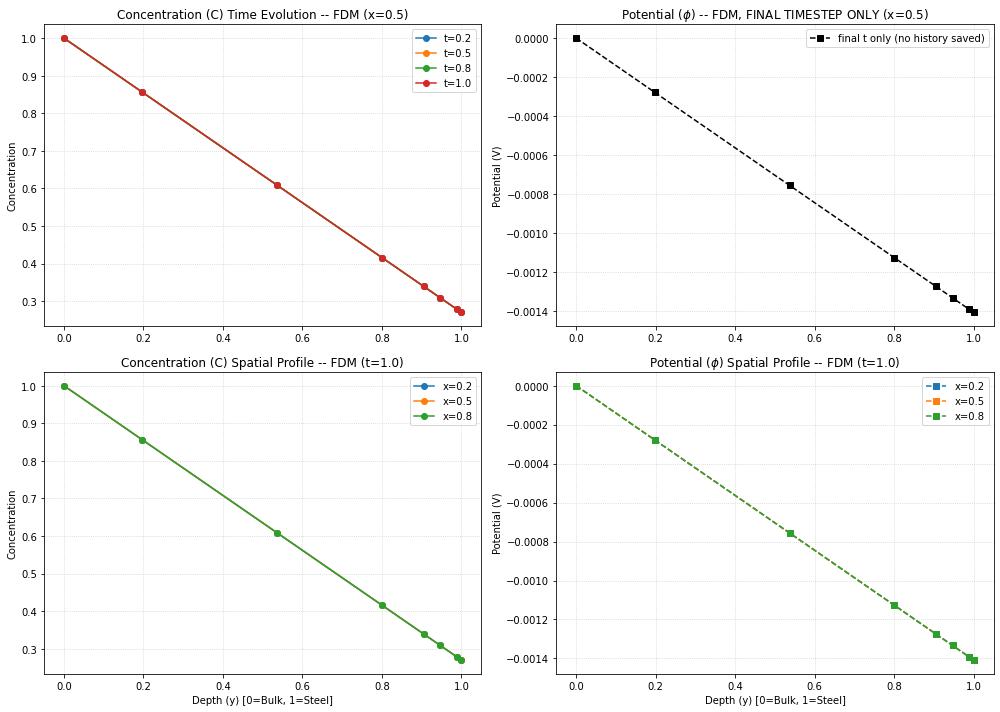

In [6]:
"""
FDM DIAGNOSTIC BOUNDARY LAYER SCAN -- mirrors diagnostic_boundary_scan_vmionet's
layout (2x2 grid: time evolution of C, spatial distribution of C and phi) so the
FDM ground truth can be visually overlaid against the PINN's own audit plot.

IMPORTANT: this script uses the FDM's y-coordinate AS-IS, with NO inversion.
y=0 is the bulk (Dirichlet C=1), y=1 is the reactive steel wall -- this matches
how solve_fdm_baseline built the grid and how the PINN's own training losses
(loss_bulk_C at y=0, flux_loss at y=1) define the same convention. If you want
to overlay this against PINN output, make sure the PINN diagnostic script is
NOT applying the "d = 1 - y" inversion, or the two plots will be comparing
opposite ends of the domain.

KNOWN LIMITATION: solve_fdm_baseline only persists the FINAL phi_field, not a
per-timestep history, so the "phi time evolution" panel here can only show a
single, fixed profile repeated across the requested t values (clearly labeled
as such) rather than genuinely evolving phi. See the bottom of this file for
a 3-line patch to solve_fdm_baseline if you want real phi(t) data instead.
"""

import numpy as np
import matplotlib.pyplot as plt


def diagnostic_boundary_scan_fdm(
    c_history_path="fdm_C_history_v21.npy",
    phi_field_path="fdm_phi_field_v21.npy",
    y_grid_path="fdm_y_grid_v21.npy",
    Nx=21,
    Nt=1000,
):
    C_history = np.load(c_history_path)   # [Nt, Nx, Ny]
    phi_field = np.load(phi_field_path)   # [Nx, Ny]  -- FINAL timestep only
    y_grid = np.load(y_grid_path)         # [Ny]

    x_grid = np.linspace(0.0, 1.0, Nx)
    dt = 1.0 / (Nt - 1)

    y_probes = [0.0, 0.2, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0]
    y_idx_probes = [int(np.argmin(np.abs(y_grid - yp))) for yp in y_probes]

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    # ------------------------------------------------------------------
    # SWEEP 1: TIME EVOLUTION OF C (fixed x=0.5)
    # ------------------------------------------------------------------
    print("\n" + "=" * 50)
    print(" FDM SWEEP 1: TIME EVOLUTION OF C (Fixed x=0.5)")
    print("=" * 50)
    x_mid_idx = Nx // 2
    t_steps = [0.2, 0.5, 0.8, 1.0]

    for t_val in t_steps:
        n_idx = int(round(t_val / dt))
        n_idx = min(n_idx, Nt - 1)
        print(f"\n--- TIME EVOLUTION: t={t_val} (step {n_idx}), x=0.5 ---")
        print(f"{'y-coord':<10} | {'C (FDM)':<15}")
        print("-" * 30)

        C_vals = []
        for yi in y_idx_probes:
            c_val = C_history[n_idx, x_mid_idx, yi]
            C_vals.append(c_val)
            print(f"{y_grid[yi]:<10.3f} | {c_val:<15.8e}")
        print("-" * 30)

        axs[0, 0].plot(y_grid[y_idx_probes], C_vals, marker='o', label=f"t={t_val}")

    axs[0, 0].set_title('Concentration (C) Time Evolution -- FDM (x=0.5)')
    axs[0, 0].set_ylabel('Concentration')

    # phi has no time history saved -- show the one available (final) profile,
    # clearly labeled, rather than fabricating intermediate timesteps
    print("\n[NOTE] phi time-history not saved by solve_fdm_baseline -- only the "
          "final-timestep phi_field is available. Plotting that single profile only.")
    phi_final_probes = [phi_field[x_mid_idx, yi] for yi in y_idx_probes]
    axs[0, 1].plot(y_grid[y_idx_probes], phi_final_probes, marker='s', linestyle='--',
                   color='black', label="final t only (no history saved)")
    axs[0, 1].set_title('Potential ($\\phi$) -- FDM, FINAL TIMESTEP ONLY (x=0.5)')
    axs[0, 1].set_ylabel('Potential (V)')

    # ------------------------------------------------------------------
    # SWEEP 2: SPATIAL DISTRIBUTION (fixed t=1.0, final saved state)
    # ------------------------------------------------------------------
    print("\n" + "=" * 50)
    print(" FDM SWEEP 2: SPATIAL DISTRIBUTION (Fixed t=1.0)")
    print("=" * 50)
    x_steps = [0.2, 0.5, 0.8]
    x_idx_steps = [int(np.argmin(np.abs(x_grid - xv))) for xv in x_steps]

    for x_val, xi in zip(x_steps, x_idx_steps):
        print(f"\n--- SPATIAL DISTRIBUTION: t=1.0, x={x_val} ---")
        print(f"{'y-coord':<10} | {'C (FDM)':<15} | {'phi (FDM) V':<15}")
        print("-" * 45)

        C_vals, phi_vals = [], []
        for yi in y_idx_probes:
            c_val = C_history[-1, xi, yi]
            phi_val = phi_field[xi, yi]
            C_vals.append(c_val)
            phi_vals.append(phi_val)
            print(f"{y_grid[yi]:<10.3f} | {c_val:<15.8e} | {phi_val:<15.8e}")
        print("-" * 45)

        axs[1, 0].plot(y_grid[y_idx_probes], C_vals, marker='o', label=f"x={x_val}")
        axs[1, 1].plot(y_grid[y_idx_probes], phi_vals, marker='s', linestyle='--', label=f"x={x_val}")

    axs[1, 0].set_title('Concentration (C) Spatial Profile -- FDM (t=1.0)')
    axs[1, 0].set_xlabel('Depth (y) [0=Bulk, 1=Steel]')
    axs[1, 0].set_ylabel('Concentration')

    axs[1, 1].set_title('Potential ($\\phi$) Spatial Profile -- FDM (t=1.0)')
    axs[1, 1].set_xlabel('Depth (y) [0=Bulk, 1=Steel]')
    axs[1, 1].set_ylabel('Potential (V)')

    for ax in axs.flat:
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend()

    plt.tight_layout()
    plt.savefig("fdm_diagnostic_scan.png", dpi=150)
    plt.show()

    return fig, axs


if __name__ == "__main__":
    diagnostic_boundary_scan_fdm()


# ----------------------------------------------------------------------------
# OPTIONAL PATCH: save phi at every timestep so the top-right panel above can
# show a real time evolution instead of one repeated final-state profile.
# In solve_fdm_baseline, add a phi_history array and fill it each step:
#
#     phi_history = np.zeros((Nt, Nx, Ny))          # add near C_history init
#     ...
#     phi_history[n] = phi_flat.reshape(Nx, Ny)      # add right after
#                                                     # C_history[n] = ... line
#     ...
#     return C_history, phi_field, y, newton_iters_log, max_rate_log, phi_history
#
# Then np.save("fdm_phi_history_v21.npy", phi_history) alongside the others,
# and this script can load it exactly like C_history for a genuine phi(t) sweep.
# ----------------------------------------------------------------------------